In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style(
    rc={"patch.force_edgecolor": True, "patch.edgecolor": "black", "font": "Palatino"}
)
sns.set_style("ticks")

plt.rcParams["font.family"] = "Palatino"  # change to palatino
plt.rcParams["font.size"] = 10  # change to palatino

In [2]:
langs = ["de", "fr", "pt", "nl", "ko"]

In [3]:
dfs = []
for lang in langs:
    path = f"../tacl_review/wmt24_chat/test.en-{lang}.csv"
    df = pd.read_csv(path)
    dfs.append(df)
df = pd.concat(dfs)
df.columns

Index(['source_language', 'target_language', 'source', 'reference', 'doc_id',
       'client_id', 'sender', 'tags', 'lp', 'baseline', 'baseline-comet',
       'greedy-7b-w-context', 'greedy-7b-w-context-comet',
       'greedy-7b-wo-context', 'greedy-7b-wo-context-comet',
       'greedy-7b-5shot-w-context', 'greedy-7b-5shot-w-context-comet',
       'greedy-7b-5shot-wo-context', 'greedy-7b-5shot-wo-context-comet',
       'greedy-7b-ft-w-context', 'greedy-7b-ft-w-context-comet',
       'greedy-7b-ft-wo-context', 'greedy-7b-ft-wo-context-comet', 'mbr',
       'mbr-comet', 'mbr-source', 'mbr-source-comet', 'mbr-hyp',
       'mbr-hyp-comet', 'greedy-70b-5shot-w-context',
       'greedy-70b-5shot-w-context-comet', 'greedy-70b-5shot-wo-context',
       'greedy-70b-5shot-wo-context-comet', 'baseline-context-comet-qe',
       'greedy-7b-w-context-context-comet-qe',
       'greedy-7b-wo-context-context-comet-qe',
       'greedy-7b-5shot-w-context-context-comet-qe',
       'greedy-7b-5shot-wo-cont

# COMET bins

In [4]:
# break df in the comet bins: [0, 0.3], [0.3, 0.4], [0.4, 0.5], [0.5, 0.6], [0.6, 0.7], [0.7, 0.8], [0.8, 0.9], [0.9, 1]
df["comet_bin"] = pd.cut(
    df[f"greedy-7b-ft-wo-context-comet"],
    bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    labels=[
        "[0, 0.5]",
        "[0.5, 0.6]",
        "[0.6, 0.7]",
        "[0.7, 0.8]",
        "[0.8, 0.9]",
        "[0.9, 1]",
    ],
)
print(df["comet_bin"].value_counts())

comet_bin
[0.9, 1]      7832
[0.8, 0.9]    1812
[0.7, 0.8]     373
[0.6, 0.7]     108
[0.5, 0.6]      34
[0, 0.5]        10
Name: count, dtype: int64


# agg lps

/mnt/data/jpombal/tmp/ipykernel_1607320/989324500.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_counts = plot_df.groupby("comet_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1607320/989324500.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1607320/989324500.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order)


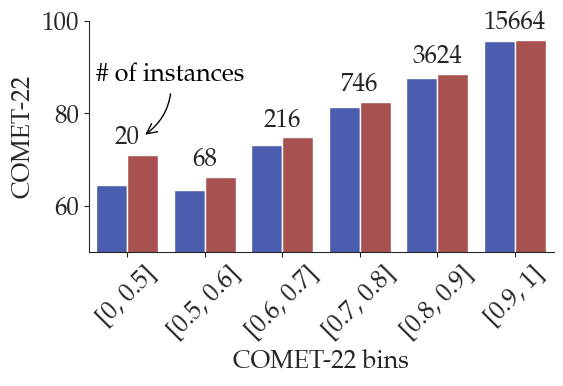

In [5]:
plot_df = df.copy()

# Convert both DataFrames into long format
plot_df = pd.melt(
    plot_df,
    id_vars=["lp", "comet_bin"],
    value_vars=[f"greedy-7b-ft-w-context-comet", f"mbr-source-comet"],
    var_name="model",
    value_name="comet",
)
plot_df["comet"] = 100 * plot_df["comet"]

# Manually order the COMET-22 bins
order = [
    "[0, 0.5]",
    "[0.5, 0.6]",
    "[0.6, 0.7]",
    "[0.7, 0.8]",
    "[0.8, 0.9]",
    "[0.9, 1]",
]

cmap = sns.color_palette(["#3953BF", "#b54343"])

fig, ax = plt.subplots(figsize=(6, 3))

# Plot for en-xx language pairs
sns.barplot(
    ax=ax,
    data=plot_df,
    x="comet_bin",
    y="comet",
    hue="model",
    errorbar=None,
    hue_order=[f"greedy-7b-ft-w-context-comet", f"mbr-source-comet"],
    palette=cmap,
    order=order,
    legend=False,
)


ax.annotate(
    "# of instances",
    xy=(0.2, 75),  # point to which the arrow will point
    xytext=(-0.4, 87),  # position of the text
    arrowprops=dict(
        arrowstyle="->", color="black", connectionstyle="arc3,rad=-0.3"  # arrow style
    ),
    fontsize=18,
    color="black",
    ha="left",
)

# Calculate counts and mean heights for en-xx
plot_df_counts = plot_df.groupby("comet_bin").size()
plot_df_means = plot_df.groupby(["comet_bin", "model"])["comet"].mean().unstack()

# Add counts to the en-xx plot
for i, bin_label in enumerate(order):
    if bin_label in plot_df_counts.index:
        count = plot_df_counts[bin_label]
        max_mean_height = plot_df_means.loc[bin_label].max()
        ax.text(
            i,
            max_mean_height + 0.01 * max_mean_height,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=18,
        )

# Set x-tick labels and axis labels
ax.set_xticklabels(order)
ax.set_xlabel("COMET-22 bins", fontsize=18)
ax.set_ylabel("COMET-22", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="x", which="major", labelsize=18, rotation=45)
# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax.get_legend_handles_labels()
# ax.legend(
#     handles=handles,
#     labels=["Greedy", "QAD-C"],
#     title="Prompt setting",
#     title_fontsize=12,
#     bbox_to_anchor=(0.5, -1),
#     fontsize=12,
#     loc="upper center",
#     ncol=2,
# )
# Despining both axes
sns.despine(ax=ax, right=True, left=False)
# ax.grid(axis="y")
plt.savefig("../plots/comet_bins_context_agg_no_mbr_vs_mbr.pdf", bbox_inches="tight")
plt.ylim(50, 100)
plt.show()

# metricx bins

In [6]:
# break df in the comet bins: [0, 0.3], [0.3, 0.4], [0.4, 0.5], [0.5, 0.6], [0.6, 0.7], [0.7, 0.8], [0.8, 0.9], [0.9, 1]
bins = [
    "[0, 0.1]",
    "[0.1, 0.25]",
    "[0.25, 0.5]",
    "[0.5, 0.75]",
    "[0.75, 1.0]",
    "[1.0, 2.0]",
]
df["metricx_bin"] = pd.cut(
    df[f"greedy-7b-ft-wo-context-metricx"],
    bins=[0, 0.1, 0.25, 0.5, 0.75, 1.0, 2.0],
    labels=bins,
)

/mnt/data/jpombal/tmp/ipykernel_1607320/2964947188.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_counts = plot_df.groupby("metricx_bin").size()
/mnt/data/jpombal/tmp/ipykernel_1607320/2964947188.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df_means = plot_df.groupby(["metricx_bin", "model"])["metricx"].mean().unstack()
/mnt/data/jpombal/tmp/ipykernel_1607320/2964947188.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order)


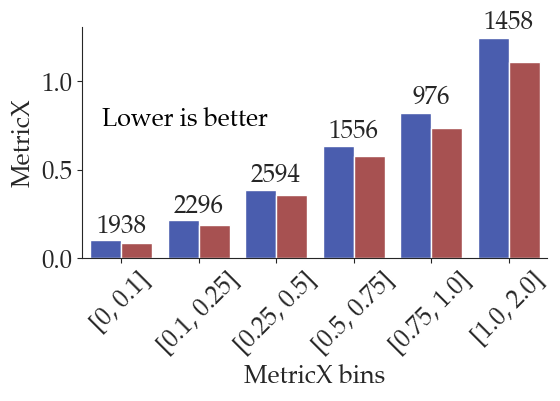

In [ ]:
plot_df = df.copy()

# Convert both DataFrames into long format
plot_df = pd.melt(
    plot_df,
    id_vars=["lp", "metricx_bin"],
    value_vars=[f"greedy-7b-ft-w-context-metricx", f"mbr-source-metricx"],
    var_name="model",
    value_name="metricx",
)

# Manually order the COMET-22 bins
order = bins


cmap = sns.color_palette(["#3953BF", "#b54343"])

fig, ax = plt.subplots(figsize=(6, 3))

# Plot for en-xx language pairs
sns.barplot(
    ax=ax,
    data=plot_df,
    x="metricx_bin",
    y="metricx",
    hue="model",
    errorbar=None,
    hue_order=[f"greedy-7b-ft-w-context-metricx", f"mbr-source-metricx"],
    palette=cmap,
    order=order,
    legend=False,
)

ax.annotate(
    "Lower is better",
    xy=(0.2, 0.75),  # point to which the arrow will point
    xytext=(-0.25, 0.75),  # position of the text
    fontsize=18,
    color="black",
    ha="left",
)

# Calculate counts and mean heights for en-xx
plot_df_counts = plot_df.groupby("metricx_bin").size()
plot_df_means = plot_df.groupby(["metricx_bin", "model"])["metricx"].mean().unstack()

# Add counts to the en-xx plot
for i, bin_label in enumerate(order):
    if bin_label in plot_df_counts.index:
        count = plot_df_counts[bin_label]
        max_mean_height = plot_df_means.loc[bin_label].max()
        ax.text(
            i,
            max_mean_height + 0.01 * max_mean_height,
            f"{count}",
            ha="center",
            va="bottom",
            fontsize=18,
        )

# Set x-tick labels and axis labels
ax.set_xticklabels(order)
ax.set_xlabel("MetricX bins", fontsize=18)
ax.set_ylabel("MetricX", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="x", which="major", labelsize=18, rotation=45)
# change legend title to "Prompt setting", with handles "With context" and "Without context"
handles, labels = ax.get_legend_handles_labels()
# ax.legend(
#    handles=handles,
#    labels=["Greedy", "QAD-C"],
#    title="Prompt setting",
#    title_fontsize=12,
#    bbox_to_anchor=(0.5, -1),
#    fontsize=12,
#    loc="upper center",
#    ncol=2,
# )
# Despining both axes
sns.despine(ax=ax, right=True, left=False)
# ax.grid(axis="y")
plt.savefig("../plots/metricx_bins_context_agg_no_mbr_vs_mbr.pdf", bbox_inches="tight")
# plt.ylim(50, 100)
plt.show()